# Market Macro-Only Research

This notebook uses a **shared hedonic residualization layer** extracted from `hedonic_modelv3.ipynb`.

Pipeline:

1. import hedonic residualization helper;
2. run the same baseline market -> geo -> project pipeline to get residualized market target;
3. train **macro-only** `Ridge` models on top of those residuals;
4. compare direct `log_market` vs `log_ret_market` reconstruction;
5. compute SHAP for both formulations.

The notebook itself does **not** define or fit geo/project blocks inline anymore. It only consumes their outputs.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from IPython.display import Image, Markdown, display
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
pd.set_option('display.max_rows', 200)
sns.set_theme(style='whitegrid')

BASE_DIR = Path.cwd()
if BASE_DIR.name != 'market':
    BASE_DIR = Path(r'C:\proga\gazprom_tex\cashflow\market')

sys.path.insert(0, str(BASE_DIR))

from hedonic_residualization import prepare_market_residual_inputs, resolve_existing_path

SELECTED_MACRO_FEATURES = [
    'eur_rub_avg_q','eur_rub_eoq','eur_rub_max_q','eur_rub_min_q','eur_rub_obs_n','family_mortgage_new_rules_active_q',
    'imoex_avg_q','imoex_eoq','imoex_max_q','imoex_min_q','imoex_obs_n','it_mortgage_new_rules_active_q',
    'mortgage_avg_ticket_mln_rub_q','mortgage_total_count_q','mortgage_total_rate_pct_q','mortgage_total_volume_mln_rub_q',
    'rgbi_avg_q','rgbi_eoq','rgbi_max_q','rgbi_min_q','rgbi_obs_n','subsidized_mortgage_2020_active_q',
    'usd_rub_avg_q','usd_rub_eoq','usd_rub_max_q','usd_rub_min_q','usd_rub_obs_n',
    'eur_rub_log_return_q','eur_rub_qoq_change','imoex_log_return_q','imoex_qoq_change',
    'mortgage_total_count_q_log_return_q','mortgage_total_count_q_qoq_change','mortgage_total_rate_pct_q_log_return_q','mortgage_total_rate_pct_q_qoq_change',
    'mortgage_total_volume_mln_rub_q_log_return_q','mortgage_total_volume_mln_rub_q_qoq_change','rgbi_log_return_q','rgbi_qoq_change',
    'usd_rub_log_return_q','usd_rub_qoq_change','key_rate_avg_q','key_rate_eoq','key_rate_max_q','key_rate_min_q','key_rate_obs_n','key_rate_log_return_q','key_rate_qoq_change',
]


C:\proga\gazprom_tex\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def regression_metrics(y_true, y_pred, name, scope):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ape = np.abs(np.exp(y_pred - y_true) - 1.0) * 100.0
    return pd.DataFrame([
        {
            'scope': scope,
            'model': name,
            'MAE_log': mean_absolute_error(y_true, y_pred),
            'RMSE_log': mean_squared_error(y_true, y_pred) ** 0.5,
            'R2': r2_score(y_true, y_pred),
            'median_APE_pct': float(np.nanmedian(ape)),
            'mean_APE_pct': float(np.nanmean(ape)),
        }
    ])


def fit_ridge_pipeline(X_train, y_train):
    n_splits = min(5, max(2, len(X_train) // 6))
    n_splits = min(n_splits, len(X_train) - 1)
    if n_splits < 2:
        n_splits = 2
    model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('reg', RidgeCV(alphas=np.logspace(-4, 4, 81), cv=TimeSeriesSplit(n_splits=n_splits))),
    ])
    model.fit(X_train, y_train)
    return model


def extract_ridge_coefficients(pipeline, feature_names, target_name):
    reg = pipeline.named_steps['reg']
    coef_frame = pd.DataFrame({
        'target': target_name,
        'feature': feature_names,
        'coefficient': reg.coef_,
    })
    intercept_frame = pd.DataFrame([{
        'target': target_name,
        'feature': '__intercept__',
        'coefficient': float(reg.intercept_),
    }])
    return pd.concat([intercept_frame, coef_frame], ignore_index=True)


def compute_shap_outputs(pipeline, X_train, X_eval, target_name):
    imputer = pipeline.named_steps['imputer']
    scaler = pipeline.named_steps['scaler']
    reg = pipeline.named_steps['reg']

    X_train_trans = scaler.transform(imputer.transform(X_train))
    X_eval_trans = scaler.transform(imputer.transform(X_eval))
    explainer = shap.Explainer(reg, X_train_trans, feature_names=list(X_train.columns))
    shap_values = explainer(X_eval_trans)

    importance = (
        pd.DataFrame({
            'target': target_name,
            'feature': list(X_train.columns),
            'mean_abs_shap': np.abs(shap_values.values).mean(axis=0),
        })
        .sort_values('mean_abs_shap', ascending=False)
        .reset_index(drop=True)
    )
    return shap_values, importance


def save_shap_plots(shap_values, feature_frame, importance, prefix, figures_dir):
    bar_path = figures_dir / f'{prefix}_shap_bar.png'
    beeswarm_path = figures_dir / f'{prefix}_shap_beeswarm.png'

    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_values.values, feature_frame, feature_names=list(feature_frame.columns), plot_type='bar', show=False, max_display=20)
    plt.tight_layout()
    plt.savefig(bar_path, dpi=160, bbox_inches='tight')
    plt.close()

    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_values.values, feature_frame, feature_names=list(feature_frame.columns), show=False, max_display=20)
    plt.tight_layout()
    plt.savefig(beeswarm_path, dpi=160, bbox_inches='tight')
    plt.close()

    importance.to_csv(figures_dir.parent / f'{prefix}_shap_importance.csv', index=False)
    return bar_path, beeswarm_path


## Load Macro Data And Shared Hedonic Residuals

Macro data is loaded here. Geo/project residualization is imported from `hedonic_residualization.py`, which contains the shared logic extracted from `hedonic_modelv3.ipynb`.

In [3]:
MACRO_PATH = resolve_existing_path([
    BASE_DIR.parent / 'macro' / 'data' / 'macro_quarterly_Moscow.csv',
    BASE_DIR / 'data' / 'macro_quarterly_Moscow.csv',
])
COVERAGE_PATH = resolve_existing_path([
    BASE_DIR.parent / 'macro' / 'data' / 'macro_quarterly_Moscow_coverage.csv',
    BASE_DIR / 'data' / 'macro_quarterly_Moscow_coverage.csv',
])

OUTPUT_DIR = BASE_DIR / 'data'
FIGURES_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

macro = pd.read_csv(MACRO_PATH)
coverage = pd.read_csv(COVERAGE_PATH)
macro['quarter'] = macro['quarter'].astype('string')

missing_features = [feature for feature in SELECTED_MACRO_FEATURES if feature not in macro.columns]
if missing_features:
    raise KeyError(f'Missing macro columns: {missing_features}')

macro = macro[['quarter'] + SELECTED_MACRO_FEATURES].copy()
residual_bundle = prepare_market_residual_inputs(BASE_DIR, macro['quarter'].tolist())

deals = residual_bundle['deals']
train_quarters = residual_bundle['train_quarters']
test_quarters = residual_bundle['test_quarters']
hedonic_diag = residual_bundle['diagnostics']
project_table = residual_bundle['project_table']

macro = macro.loc[macro['quarter'].isin(sorted(set(deals['quarter']), key=lambda q: pd.Period(q, freq='Q')))].copy()
feature_coverage = coverage.loc[coverage['feature'].isin(SELECTED_MACRO_FEATURES)].copy()

display(pd.DataFrame([{
    'macro_path': str(MACRO_PATH),
    'residual_source': str(BASE_DIR / 'hedonic_residualization.py'),
    'output_dir': str(OUTPUT_DIR),
    'n_deals': int(len(deals)),
    'train_first': train_quarters[0],
    'train_last': train_quarters[-1],
    'test_first': test_quarters[0],
    'test_last': test_quarters[-1],
    'n_macro_features': len(SELECTED_MACRO_FEATURES),
}]))

display(pd.DataFrame([hedonic_diag]).T.rename(columns={0: 'value'}))
display(feature_coverage.sort_values('feature').reset_index(drop=True))
assert macro[SELECTED_MACRO_FEATURES].isna().sum().sum() == 0


,macro_path,residual_source,output_dir,n_deals,train_first,train_last,test_first,test_last,n_macro_features
0,C:\proga\gazprom_tex\cashflow\macro\data\macro...,C:\proga\gazprom_tex\cashflow\market\hedonic_r...,C:\proga\gazprom_tex\cashflow\market\data,577404,2015Q1,2022Q3,2022Q4,2026Q1,48


,value
deals_path,C:\proga\gazprom_tex\data\deals_with_real_geo_...
train_first,2015Q1
train_last,2022Q3
test_first,2022Q4
test_last,2026Q1
baseline_market_train_r2,0.355608
geo_train_r2,0.538708
geo_test_r2,0.277727
quality_train_r2,0.262718
quality_test_r2,0.151963


,feature,first_quarter,last_quarter,non_null_quarters
0,eur_rub_avg_q,2013Q1,2026Q2,54
1,eur_rub_eoq,2013Q1,2026Q2,54
2,eur_rub_log_return_q,2013Q2,2026Q2,53
3,eur_rub_max_q,2013Q1,2026Q2,54
4,eur_rub_min_q,2013Q1,2026Q2,54
5,eur_rub_obs_n,2013Q1,2026Q2,54
6,eur_rub_qoq_change,2013Q2,2026Q2,53
7,family_mortgage_new_rules_active_q,2013Q1,2026Q2,54
8,imoex_avg_q,2013Q1,2026Q2,54
9,imoex_eoq,2013Q1,2026Q2,54


## Residual Target Coming From Shared Hedonic Layer

At this point the notebook already has:

- `geo_score`
- `project_score`
- `market_target = log_price_sqm - geo_score - project_score`

These are produced by the shared helper, not by notebook-local geo/project code.

In [4]:
display(deals[['quarter', 'log_price_sqm', 'baseline_market_log_price', 'geo_score', 'project_score', 'market_target']].head())
print('projects_with_premium', project_table.shape[0])


,quarter,log_price_sqm,baseline_market_log_price,geo_score,project_score,market_target
0,2015Q1,12.510335,12.510335,0.297753,-0.520557,12.733139
1,2015Q2,12.240537,12.194887,0.185733,-0.219653,12.274457
2,2015Q2,12.149238,12.194887,0.042015,-0.029562,12.136785
3,2015Q2,12.102577,12.194887,0.042015,-0.116700,12.177263
4,2015Q2,12.294560,12.194887,0.185733,-0.194042,12.302868


projects_with_premium 508


## Quarterly Market Targets

Two market targets are compared:

- direct quarterly level: `market_log_level_q`
- quarter-over-quarter change: `market_log_ret_q`


In [5]:
quarter_panel = (
    deals.groupby('quarter', as_index=False)
    .agg(
        n_deals=('log_price_sqm', 'size'),
        market_log_level_q=('market_target', 'median'),
        actual_log_price_median=('log_price_sqm', 'median'),
        geo_score_q=('geo_score', 'median'),
        project_score_q=('project_score', 'median'),
    )
)
quarter_panel['quarter_period'] = pd.PeriodIndex(quarter_panel['quarter'].astype('string'), freq='Q')
quarter_panel = quarter_panel.merge(macro, on='quarter', how='left').sort_values('quarter_period').reset_index(drop=True)
quarter_panel['is_train'] = quarter_panel['quarter'].isin(train_quarters)
quarter_panel['is_test'] = quarter_panel['quarter'].isin(test_quarters)
quarter_panel['market_log_ret_q'] = quarter_panel['market_log_level_q'].diff()

display(quarter_panel[['quarter', 'n_deals', 'market_log_level_q', 'market_log_ret_q']].head(15))
display(quarter_panel[['quarter', 'n_deals', 'market_log_level_q', 'market_log_ret_q']].tail(15))


,quarter,n_deals,market_log_level_q,market_log_ret_q
0,2015Q1,1,12.733139,NaN
1,2015Q2,4,12.225860,-0.507279
2,2015Q3,2,12.353107,0.127247
3,2015Q4,1352,11.979400,-0.373707
4,2016Q1,3798,11.934835,-0.044564
5,2016Q2,5676,11.931919,-0.002916
6,2016Q3,7781,11.968232,0.036313
7,2016Q4,8858,11.963010,-0.005222
8,2017Q1,7276,11.961174,-0.001836
9,2017Q2,7880,11.976701,0.015526


,quarter,n_deals,market_log_level_q,market_log_ret_q
30,2022Q3,14728,12.608647,-0.024712
31,2022Q4,15609,12.606692,-0.001955
32,2023Q1,13899,12.614200,0.007508
33,2023Q2,16438,12.647176,0.032976
34,2023Q3,24583,12.704216,0.057040
35,2023Q4,24599,12.765606,0.061390
36,2024Q1,14347,12.790815,0.025209
37,2024Q2,20125,12.841057,0.050243
38,2024Q3,12940,12.817764,-0.023294
39,2024Q4,19136,12.822821,0.005057


## Macro-Only Ridge Models

This notebook uses only one model family: `Ridge`.

- Model A: `macro -> market_log_level_q`
- Model B: `macro -> market_log_ret_q`, then reconstruct `market_log_level_q` from the last known train level


In [6]:
level_train_mask = quarter_panel['is_train']
level_test_mask = quarter_panel['is_test']
ret_train_mask = quarter_panel['is_train'] & quarter_panel['market_log_ret_q'].notna()
ret_test_mask = quarter_panel['is_test'] & quarter_panel['market_log_ret_q'].notna()

level_model = fit_ridge_pipeline(
    quarter_panel.loc[level_train_mask, SELECTED_MACRO_FEATURES],
    quarter_panel.loc[level_train_mask, 'market_log_level_q'],
)
return_model = fit_ridge_pipeline(
    quarter_panel.loc[ret_train_mask, SELECTED_MACRO_FEATURES],
    quarter_panel.loc[ret_train_mask, 'market_log_ret_q'],
)

quarter_panel['pred_market_log_level_direct'] = level_model.predict(quarter_panel[SELECTED_MACRO_FEATURES])
quarter_panel['pred_market_log_ret'] = return_model.predict(quarter_panel[SELECTED_MACRO_FEATURES])

quarter_panel['pred_market_log_level_from_ret'] = np.nan
last_train_idx = quarter_panel.index[quarter_panel['is_train']].max()
quarter_panel.loc[last_train_idx, 'pred_market_log_level_from_ret'] = quarter_panel.loc[last_train_idx, 'market_log_level_q']
for idx in range(last_train_idx + 1, len(quarter_panel)):
    quarter_panel.loc[idx, 'pred_market_log_level_from_ret'] = quarter_panel.loc[idx - 1, 'pred_market_log_level_from_ret'] + quarter_panel.loc[idx, 'pred_market_log_ret']

quarter_panel['pred_market_log_level_from_ret_train_path'] = np.nan
first_idx = quarter_panel.index.min()
quarter_panel.loc[first_idx, 'pred_market_log_level_from_ret_train_path'] = quarter_panel.loc[first_idx, 'market_log_level_q']
for idx in range(first_idx + 1, len(quarter_panel)):
    quarter_panel.loc[idx, 'pred_market_log_level_from_ret_train_path'] = quarter_panel.loc[idx - 1, 'pred_market_log_level_from_ret_train_path'] + quarter_panel.loc[idx, 'pred_market_log_ret']

coefficients = pd.concat([
    extract_ridge_coefficients(level_model, SELECTED_MACRO_FEATURES, 'market_log_level_q'),
    extract_ridge_coefficients(return_model, SELECTED_MACRO_FEATURES, 'market_log_ret_q'),
], ignore_index=True)

display(pd.DataFrame([
    {'target': 'market_log_level_q', 'alpha': float(level_model.named_steps['reg'].alpha_)},
    {'target': 'market_log_ret_q', 'alpha': float(return_model.named_steps['reg'].alpha_)},
]))


,target,alpha
0,market_log_level_q,6.309573
1,market_log_ret_q,79.432823


## Metrics

Comparison is reported on:

- quarterly level prediction
- quarterly return prediction
- final deal-level prediction after adding back fixed `geo_score + project_score`


In [7]:
quarter_metrics = pd.concat([
    regression_metrics(
        quarter_panel.loc[level_test_mask, 'market_log_level_q'],
        quarter_panel.loc[level_test_mask, 'pred_market_log_level_direct'],
        name='ridge_macro_direct_level',
        scope='quarterly_level_test',
    ),
    regression_metrics(
        quarter_panel.loc[level_test_mask, 'market_log_level_q'],
        quarter_panel.loc[level_test_mask, 'pred_market_log_level_from_ret'],
        name='ridge_macro_return_reconstructed_level',
        scope='quarterly_level_test',
    ),
    regression_metrics(
        quarter_panel.loc[ret_test_mask, 'market_log_ret_q'],
        quarter_panel.loc[ret_test_mask, 'pred_market_log_ret'],
        name='ridge_macro_return',
        scope='quarterly_return_test',
    ),
], ignore_index=True)

deals = deals.merge(
    quarter_panel[['quarter', 'pred_market_log_level_direct', 'pred_market_log_level_from_ret']],
    on='quarter',
    how='left',
)
deals['pred_log_price_direct'] = deals['pred_market_log_level_direct'] + deals['geo_score'] + deals['project_score']
deals['pred_log_price_from_ret'] = deals['pred_market_log_level_from_ret'] + deals['geo_score'] + deals['project_score']

deal_metrics = pd.concat([
    regression_metrics(
        deals.loc[deals['is_test'], 'log_price_sqm'],
        deals.loc[deals['is_test'], 'pred_log_price_direct'],
        name='deal_level_direct_level_market',
        scope='deal_level_test',
    ),
    regression_metrics(
        deals.loc[deals['is_test'], 'log_price_sqm'],
        deals.loc[deals['is_test'], 'pred_log_price_from_ret'],
        name='deal_level_return_reconstructed_market',
        scope='deal_level_test',
    ),
], ignore_index=True)

metrics_summary = pd.concat([quarter_metrics, deal_metrics], ignore_index=True)
display(metrics_summary.sort_values(['scope', 'RMSE_log', 'MAE_log']).reset_index(drop=True))


,scope,model,MAE_log,RMSE_log,R2,median_APE_pct,mean_APE_pct
0,deal_level_test,deal_level_direct_level_market,0.226426,0.310341,0.226641,16.465746,19.788049
1,deal_level_test,deal_level_return_reconstructed_market,0.367466,0.489344,-0.922781,24.084377,27.955839
2,quarterly_level_test,ridge_macro_direct_level,0.175705,0.227107,-1.713863,14.222513,15.455766
3,quarterly_level_test,ridge_macro_return_reconstructed_level,0.361925,0.473837,-10.813691,24.348658,27.263947
4,quarterly_return_test,ridge_macro_return,0.070678,0.085196,-7.944016,5.650846,6.721578


## Plots

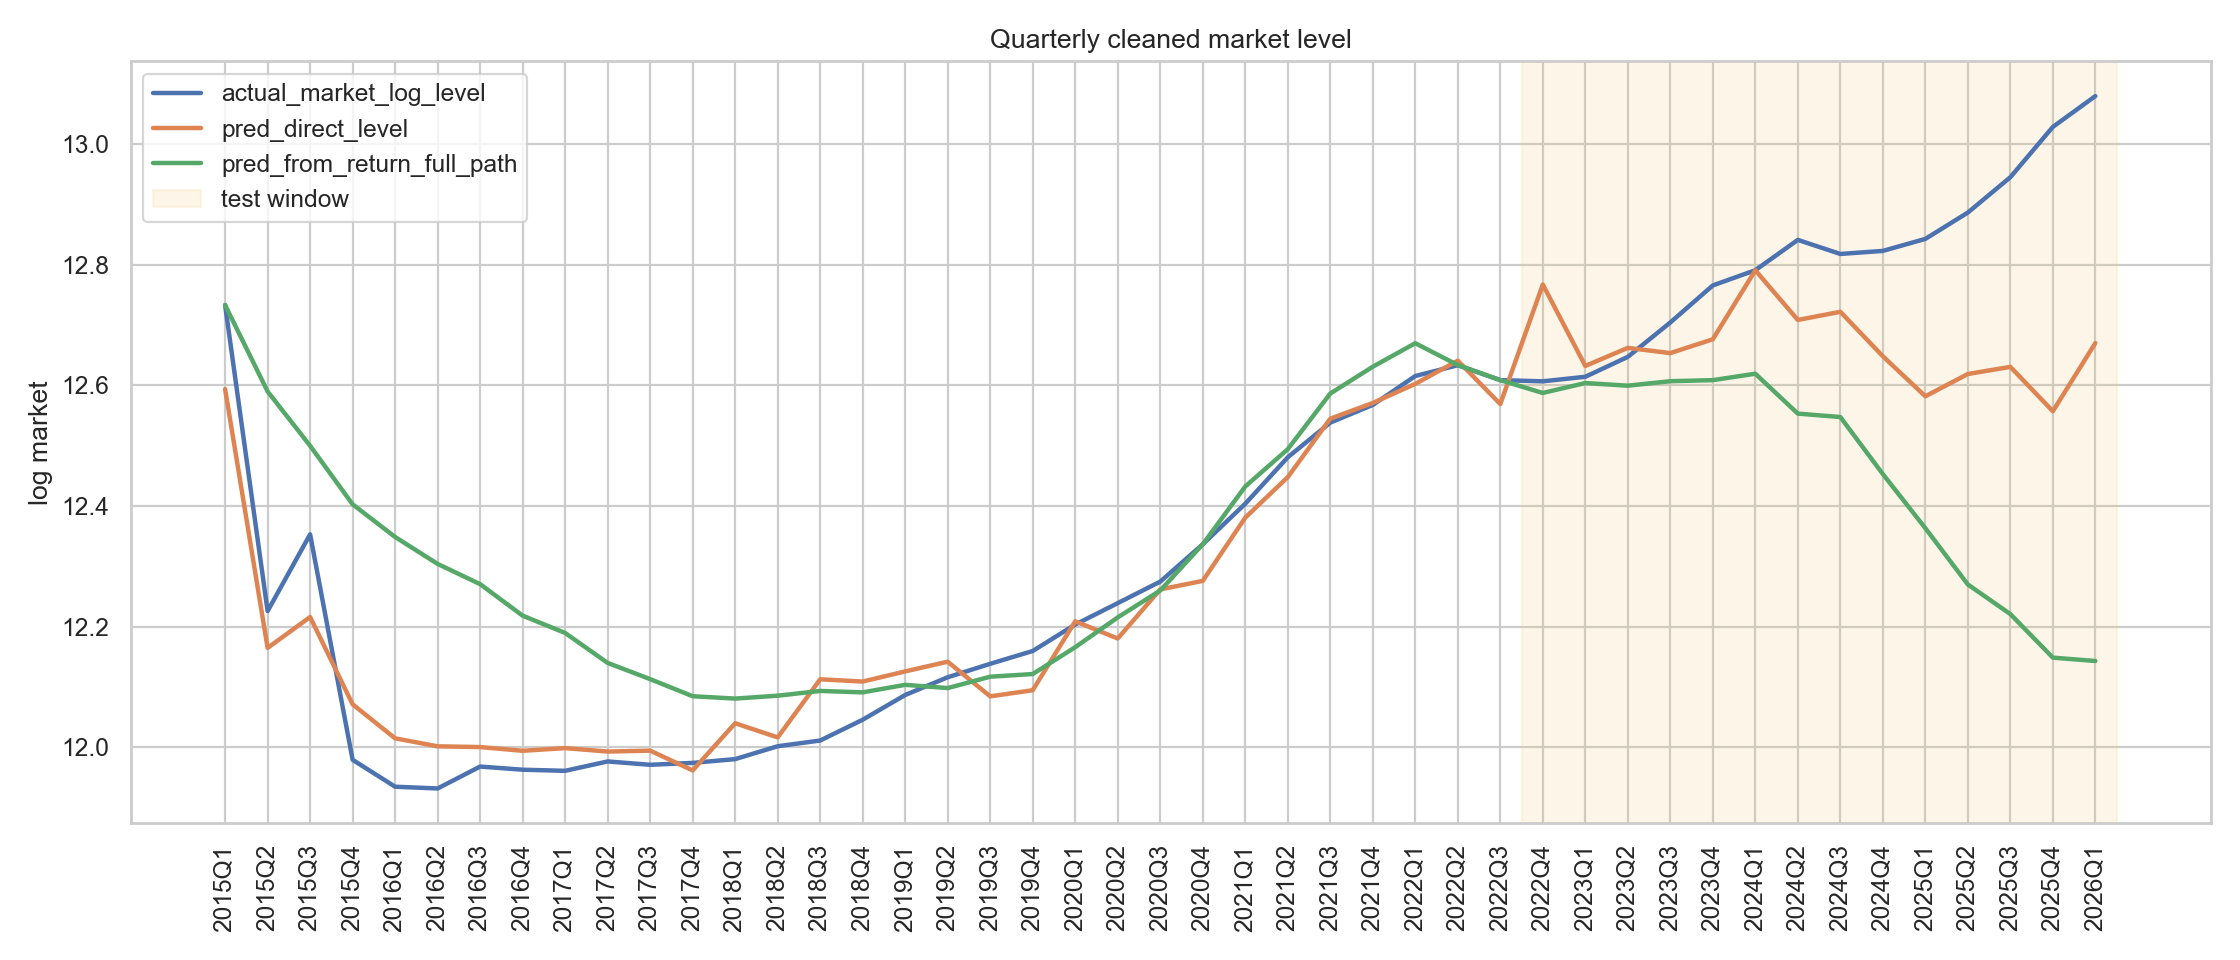

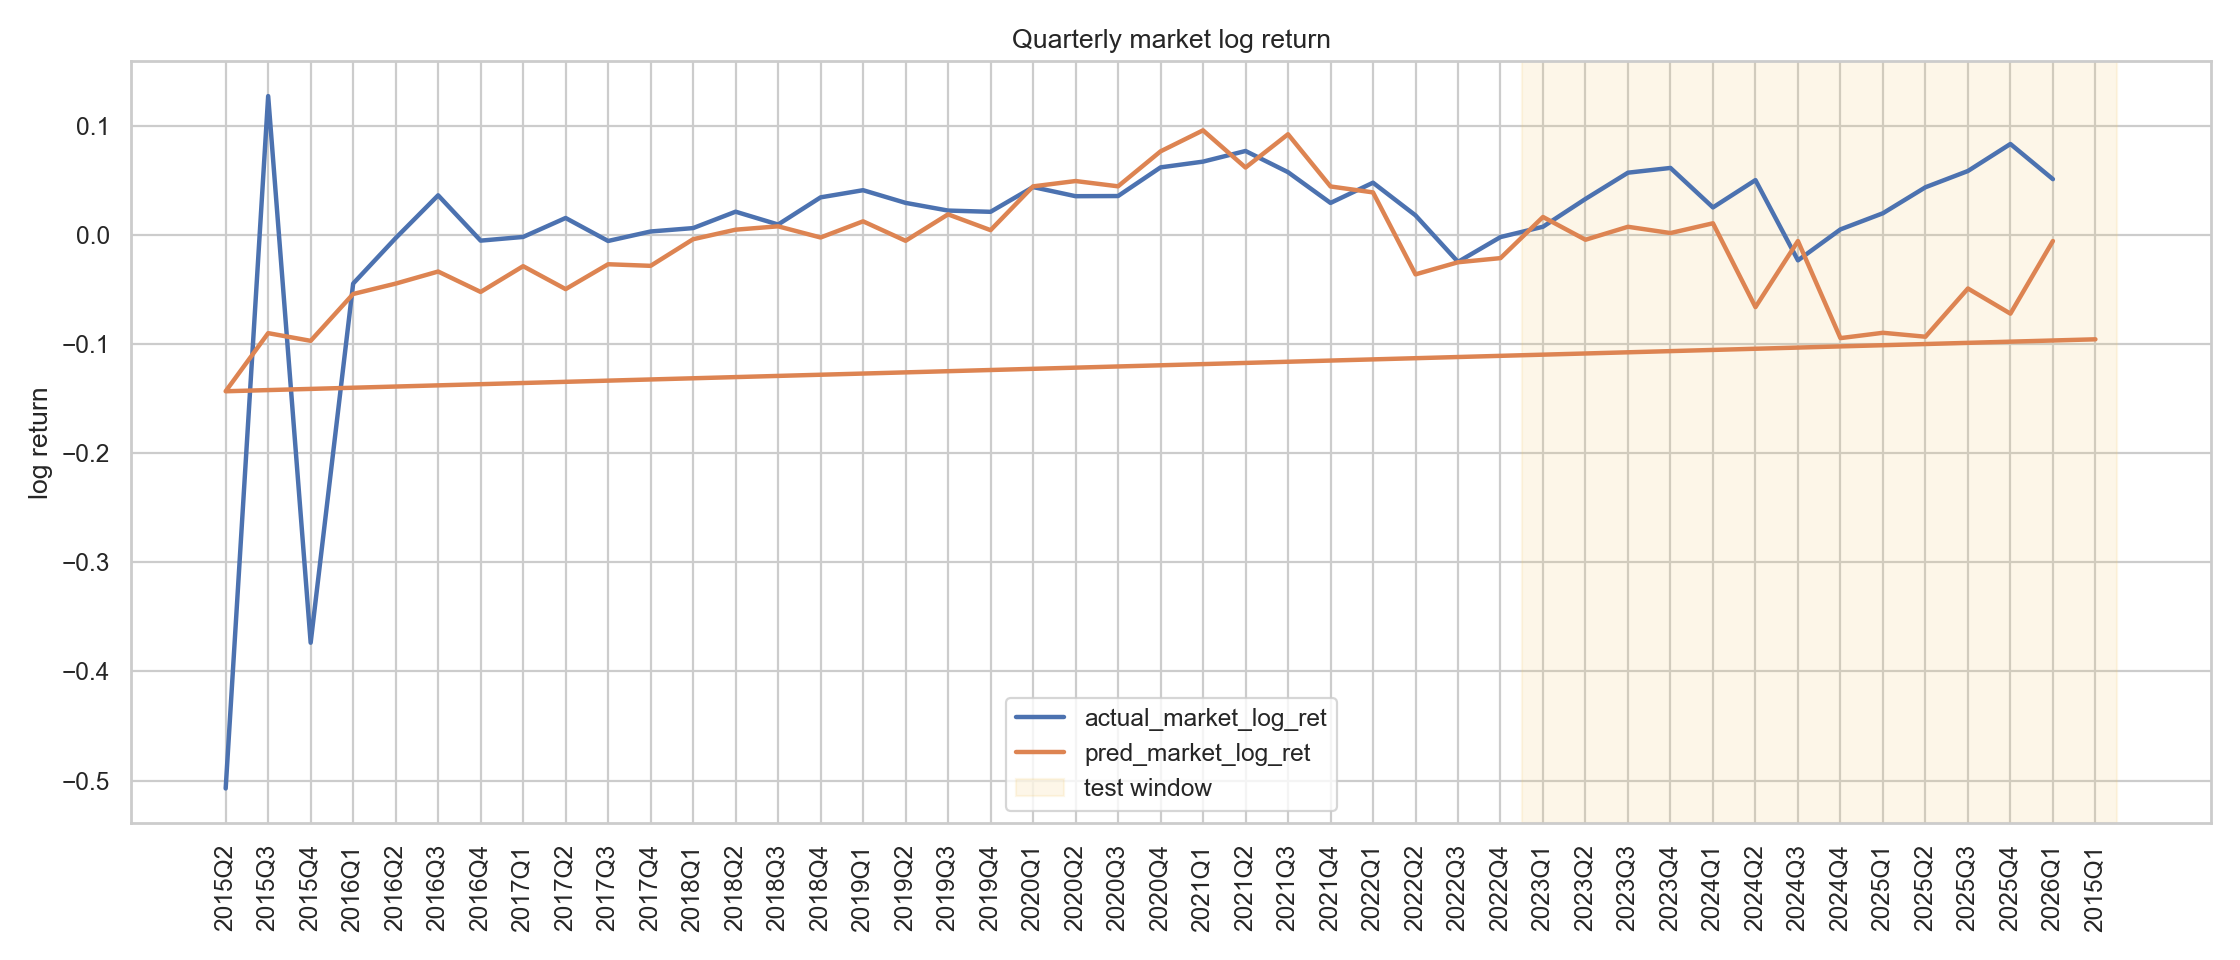

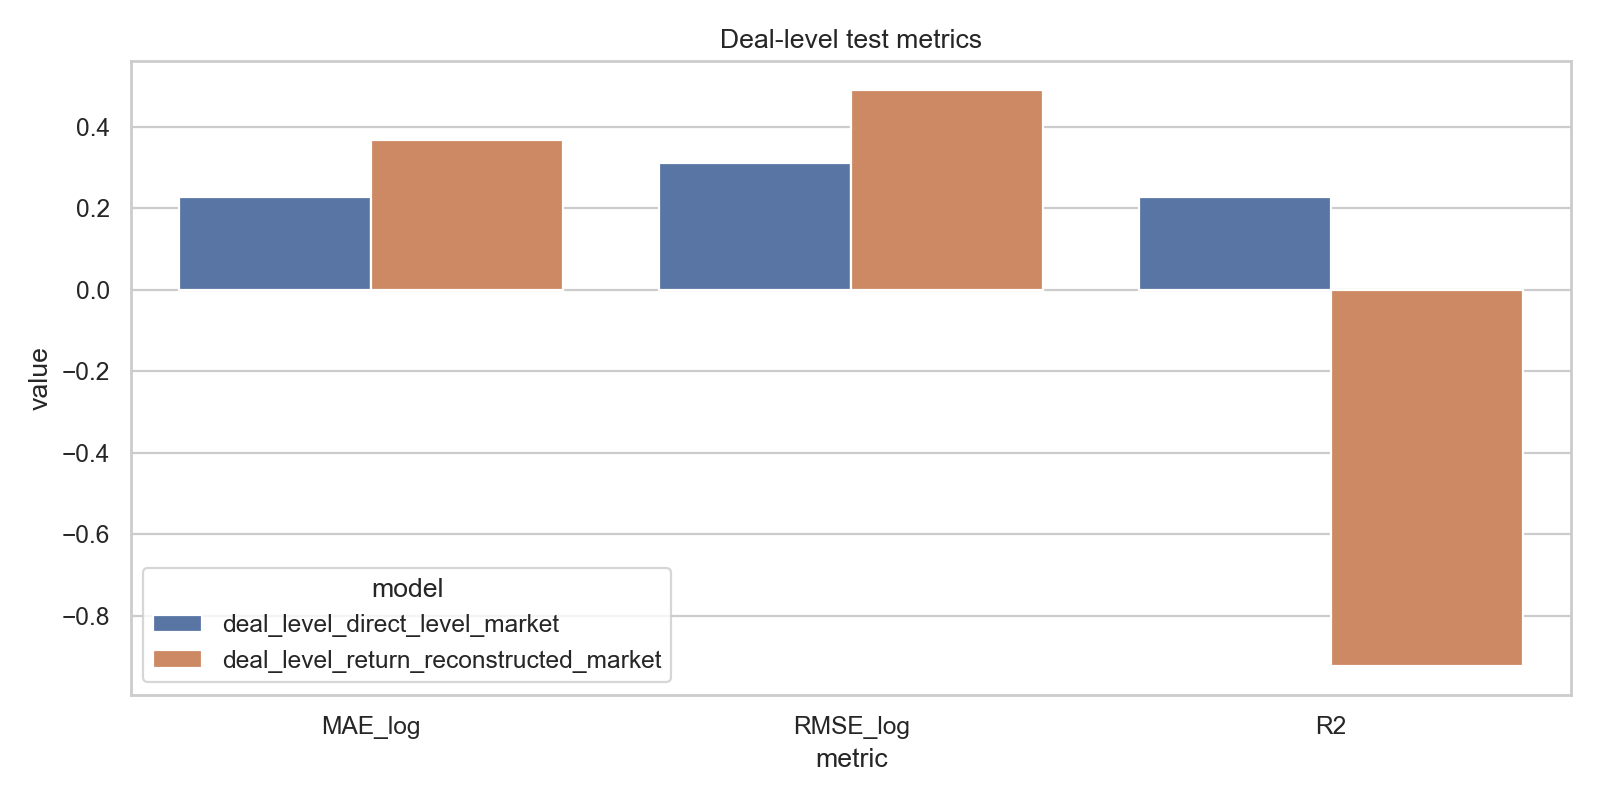

In [8]:
market_level_plot = FIGURES_DIR / 'market_level_actual_vs_predicted.png'
market_return_plot = FIGURES_DIR / 'market_return_actual_vs_predicted.png'
deal_metric_plot = FIGURES_DIR / 'deal_level_metric_comparison.png'

plot_panel = quarter_panel.copy()
plot_panel['idx'] = np.arange(len(plot_panel))
test_start_idx = plot_panel.loc[plot_panel['is_test'], 'idx'].min()

plt.figure(figsize=(14, 6))
plt.plot(plot_panel['quarter'], plot_panel['market_log_level_q'], label='actual_market_log_level', linewidth=2)
plt.plot(plot_panel['quarter'], plot_panel['pred_market_log_level_direct'], label='pred_direct_level', linewidth=2)
plt.plot(plot_panel['quarter'], plot_panel['pred_market_log_level_from_ret_train_path'], label='pred_from_return_full_path', linewidth=2)
plt.axvspan(test_start_idx - 0.5, len(plot_panel) - 0.5, color='#f3c969', alpha=0.15, label='test window')
plt.xticks(rotation=90)
plt.title('Quarterly cleaned market level')
plt.ylabel('log market')
plt.tight_layout()
plt.legend()
plt.savefig(market_level_plot, dpi=160)
plt.close()

plt.figure(figsize=(14, 6))
ret_panel = plot_panel.loc[plot_panel['market_log_ret_q'].notna()].copy()
plt.plot(ret_panel['quarter'], ret_panel['market_log_ret_q'], label='actual_market_log_ret', linewidth=2)
plt.plot(plot_panel['quarter'], plot_panel['pred_market_log_ret'], label='pred_market_log_ret', linewidth=2)
plt.axvspan(test_start_idx - 0.5, len(plot_panel) - 0.5, color='#f3c969', alpha=0.15, label='test window')
plt.xticks(rotation=90)
plt.title('Quarterly market log return')
plt.ylabel('log return')
plt.tight_layout()
plt.legend()
plt.savefig(market_return_plot, dpi=160)
plt.close()

deal_plot_frame = deal_metrics[['model', 'MAE_log', 'RMSE_log', 'R2']].melt(id_vars='model', var_name='metric', value_name='value')
plt.figure(figsize=(10, 5))
sns.barplot(data=deal_plot_frame, x='metric', y='value', hue='model')
plt.title('Deal-level test metrics')
plt.tight_layout()
plt.savefig(deal_metric_plot, dpi=160)
plt.close()

display(Image(filename=str(market_level_plot)))
display(Image(filename=str(market_return_plot)))
display(Image(filename=str(deal_metric_plot)))


## SHAP

SHAP is calculated on the test quarters for both target formulations.

,target,feature,mean_abs_shap
0,market_log_level_q,mortgage_avg_ticket_mln_rub_q,0.110097
1,market_log_level_q,subsidized_mortgage_2020_active_q,0.081008
2,market_log_level_q,rgbi_eoq,0.057778
3,market_log_level_q,usd_rub_min_q,0.056181
4,market_log_level_q,key_rate_max_q,0.053067
5,market_log_level_q,rgbi_min_q,0.051998
6,market_log_level_q,eur_rub_min_q,0.048841
7,market_log_level_q,rgbi_avg_q,0.043639
8,market_log_level_q,mortgage_total_volume_mln_rub_q,0.038717
9,market_log_level_q,key_rate_avg_q,0.037442


,target,feature,mean_abs_shap
0,market_log_ret_q,rgbi_max_q,0.013187
1,market_log_ret_q,rgbi_eoq,0.013180
2,market_log_ret_q,key_rate_min_q,0.011835
3,market_log_ret_q,rgbi_avg_q,0.011268
4,market_log_ret_q,key_rate_avg_q,0.010519
5,market_log_ret_q,rgbi_min_q,0.009545
6,market_log_ret_q,usd_rub_avg_q,0.009288
7,market_log_ret_q,mortgage_total_rate_pct_q_qoq_change,0.009187
8,market_log_ret_q,eur_rub_avg_q,0.006845
9,market_log_ret_q,mortgage_total_volume_mln_rub_q_log_return_q,0.006824


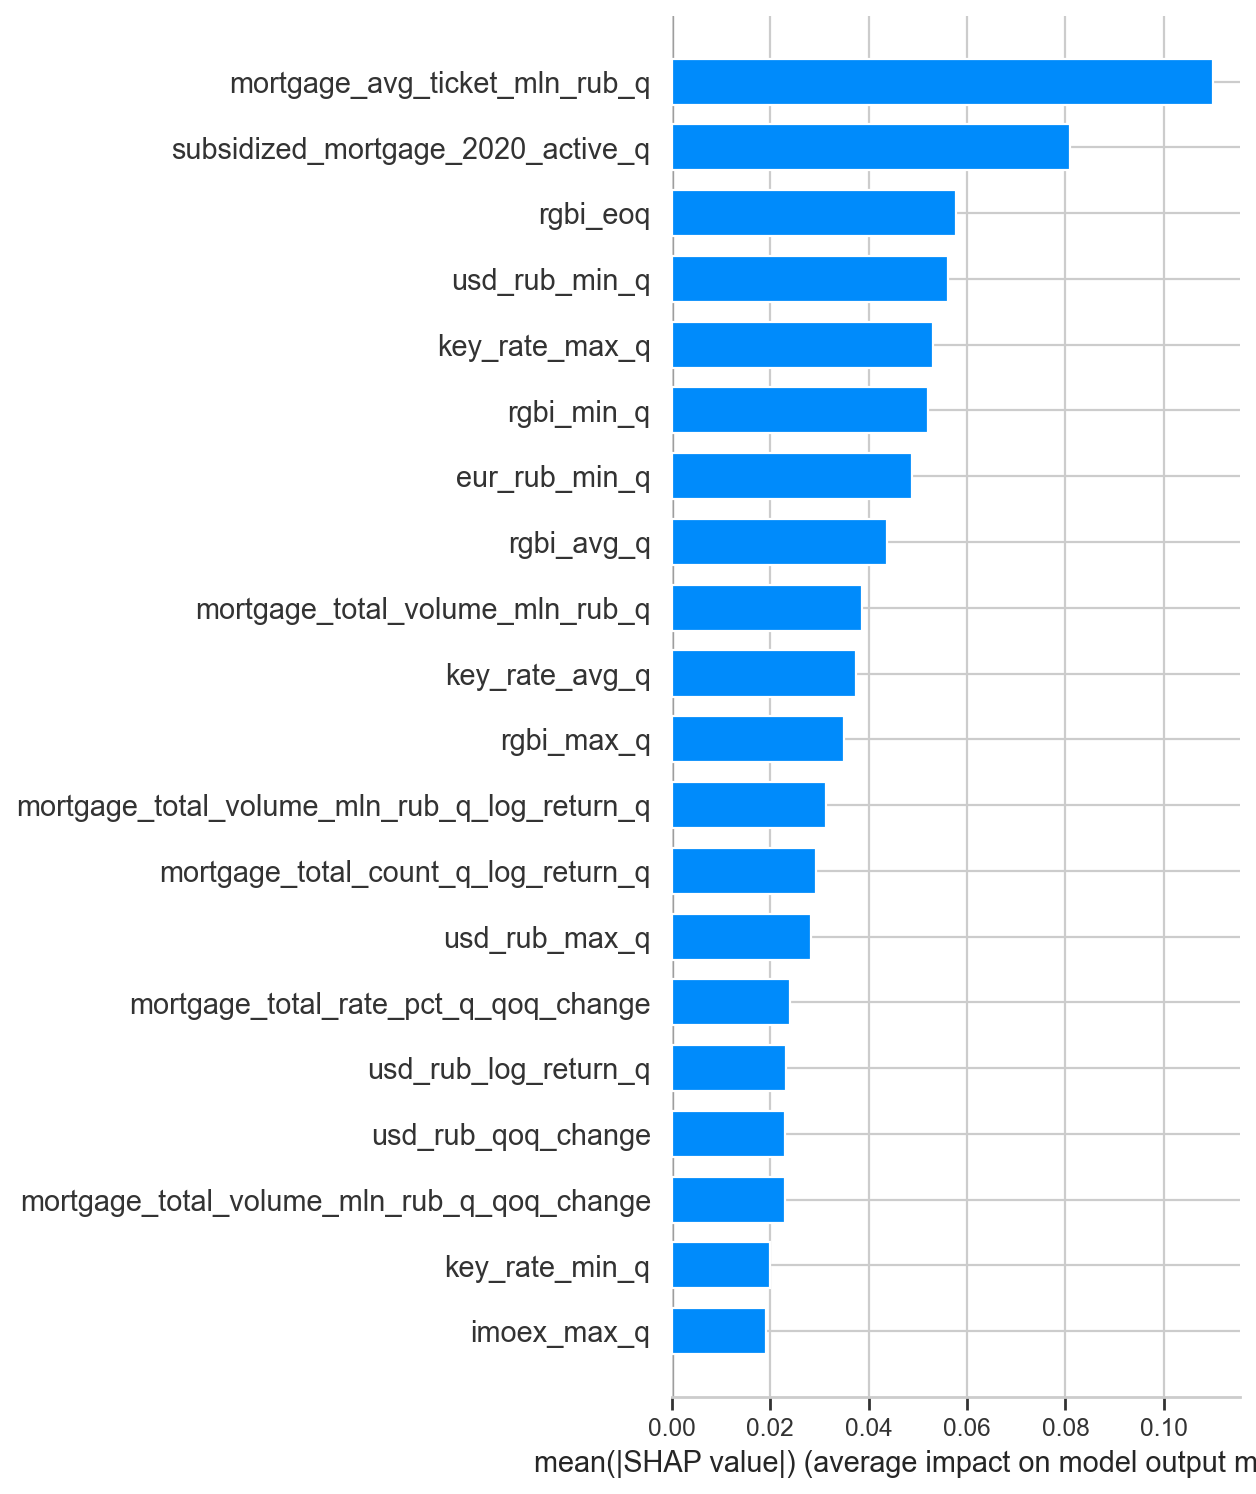

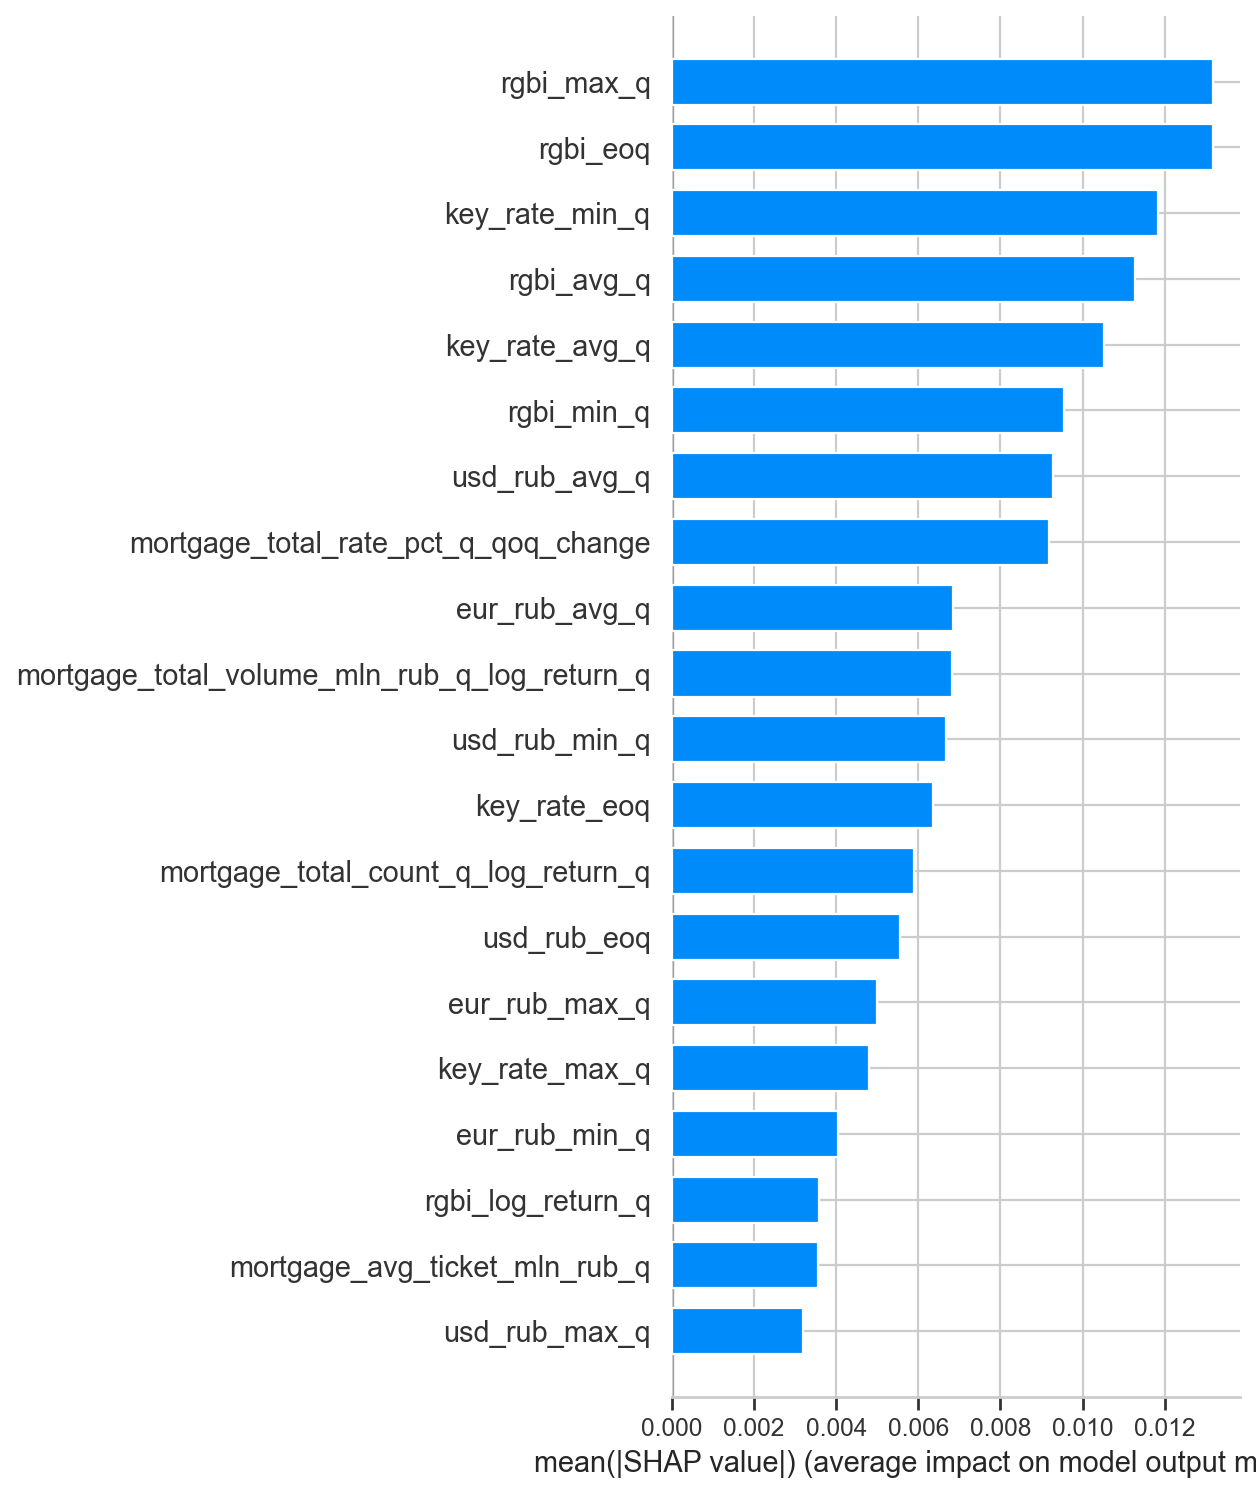

In [9]:
level_shap_values, level_shap_importance = compute_shap_outputs(
    level_model,
    quarter_panel.loc[level_train_mask, SELECTED_MACRO_FEATURES],
    quarter_panel.loc[level_test_mask, SELECTED_MACRO_FEATURES],
    'market_log_level_q',
)
return_shap_values, return_shap_importance = compute_shap_outputs(
    return_model,
    quarter_panel.loc[ret_train_mask, SELECTED_MACRO_FEATURES],
    quarter_panel.loc[ret_test_mask, SELECTED_MACRO_FEATURES],
    'market_log_ret_q',
)

level_shap_bar, level_shap_beeswarm = save_shap_plots(
    level_shap_values,
    quarter_panel.loc[level_test_mask, SELECTED_MACRO_FEATURES],
    level_shap_importance,
    'market_log_level',
    FIGURES_DIR,
)
return_shap_bar, return_shap_beeswarm = save_shap_plots(
    return_shap_values,
    quarter_panel.loc[ret_test_mask, SELECTED_MACRO_FEATURES],
    return_shap_importance,
    'market_log_return',
    FIGURES_DIR,
)

display(level_shap_importance.head(15))
display(return_shap_importance.head(15))
display(Image(filename=str(level_shap_bar)))
display(Image(filename=str(return_shap_bar)))


## Save Artifacts

In [10]:
metrics_path = OUTPUT_DIR / 'metrics_summary.csv'
coef_path = OUTPUT_DIR / 'model_coefficients.csv'
quarter_path = OUTPUT_DIR / 'quarterly_market_predictions.csv'
deal_parquet_path = OUTPUT_DIR / 'test_predictions.parquet'

metrics_summary.to_csv(metrics_path, index=False)
coefficients.to_csv(coef_path, index=False)
quarter_panel.to_csv(quarter_path, index=False)
deals.loc[deals['is_test']].to_parquet(deal_parquet_path, index=False)

best_quarter_model = quarter_metrics.loc[quarter_metrics['scope'].eq('quarterly_level_test')].sort_values(['RMSE_log', 'MAE_log']).iloc[0]
best_deal_model = deal_metrics.sort_values(['RMSE_log', 'MAE_log']).iloc[0]

summary_markdown = f'''### Market Macro-Only Summary

- Notebook location: `{BASE_DIR / 'market_macro_only_research.ipynb'}`
- Shared residualization helper: `{BASE_DIR / 'hedonic_residualization.py'}`
- Train window: `{train_quarters[0]}` .. `{train_quarters[-1]}`
- Test window: `{test_quarters[0]}` .. `{test_quarters[-1]}`
- Model family: `Ridge`
- Macro feature count: `{len(SELECTED_MACRO_FEATURES)}`
- Quarterly level winner: `{best_quarter_model['model']}` with `RMSE_log={best_quarter_model['RMSE_log']:.4f}`, `MAE_log={best_quarter_model['MAE_log']:.4f}`
- Deal-level winner: `{best_deal_model['model']}` with `RMSE_log={best_deal_model['RMSE_log']:.4f}`, `MAE_log={best_deal_model['MAE_log']:.4f}`, `R2={best_deal_model['R2']:.4f}`
- Top SHAP features for level: `{', '.join(level_shap_importance.head(5)['feature'].tolist())}`
- Top SHAP features for return: `{', '.join(return_shap_importance.head(5)['feature'].tolist())}`
- Outputs written to: `{OUTPUT_DIR}`
'''.strip()

display(Markdown(summary_markdown))
display(pd.DataFrame([
    {'artifact': 'metrics_summary', 'path': str(metrics_path)},
    {'artifact': 'model_coefficients', 'path': str(coef_path)},
    {'artifact': 'quarterly_predictions', 'path': str(quarter_path)},
    {'artifact': 'test_predictions_parquet', 'path': str(deal_parquet_path)},
    {'artifact': 'figures_dir', 'path': str(FIGURES_DIR)},
]))


### Market Macro-Only Summary

- Notebook location: `C:\proga\gazprom_tex\cashflow\market\market_macro_only_research.ipynb`
- Shared residualization helper: `C:\proga\gazprom_tex\cashflow\market\hedonic_residualization.py`
- Train window: `2015Q1` .. `2022Q3`
- Test window: `2022Q4` .. `2026Q1`
- Model family: `Ridge`
- Macro feature count: `48`
- Quarterly level winner: `ridge_macro_direct_level` with `RMSE_log=0.2271`, `MAE_log=0.1757`
- Deal-level winner: `deal_level_direct_level_market` with `RMSE_log=0.3103`, `MAE_log=0.2264`, `R2=0.2266`
- Top SHAP features for level: `mortgage_avg_ticket_mln_rub_q, subsidized_mortgage_2020_active_q, rgbi_eoq, usd_rub_min_q, key_rate_max_q`
- Top SHAP features for return: `rgbi_max_q, rgbi_eoq, key_rate_min_q, rgbi_avg_q, key_rate_avg_q`
- Outputs written to: `C:\proga\gazprom_tex\cashflow\market\data`

,artifact,path
0,metrics_summary,C:\proga\gazprom_tex\cashflow\market\data\metr...
1,model_coefficients,C:\proga\gazprom_tex\cashflow\market\data\mode...
2,quarterly_predictions,C:\proga\gazprom_tex\cashflow\market\data\quar...
3,test_predictions_parquet,C:\proga\gazprom_tex\cashflow\market\data\test...
4,figures_dir,C:\proga\gazprom_tex\cashflow\market\data\figures
